# YouTube Virality Modeling — 4 Model Comparison

This notebook runs four class-aligned models on the API-enriched YouTube dataset:
- Elastic Net
- KNN Regressor
- Random Forest Regressor
- MLP Regressor

Primary target: `log1p(view_count)` using `yt_view_count` when available, otherwise `views`.

> Note: To avoid leakage, this notebook **does not** use likes/comments as predictors when predicting views.

In [8]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [9]:
# ---- Load data ----
DATA_PATH = '../youtube_data_enriched.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print('Columns sample:', df.columns[:20].tolist())

Shape: (17589, 45)
Columns sample: ['video_id', 'duration', 'bitrate', 'bitrate(video)', 'height', 'width', 'frame rate', 'frame rate(est.)', 'codec', 'category', 'url', 'title', 'description', 'hashtags', 'views', 'likes', 'comments', 'yt_title', 'yt_description', 'yt_published_at']


In [20]:
# Feature engineering + variable audit
def pick_col(primary, fallback, frame):
    return primary if primary in frame.columns else fallback

views_col = pick_col('yt_view_count', 'views', df)
title_col = pick_col('yt_title', 'title', df)
desc_col = pick_col('yt_description', 'description', df)
duration_col = pick_col('yt_duration_sec', 'duration', df)

df_model = df.copy()


# Log-transform heavy-tailed channel scale features
for col in ['yt_subscriber_count', 'yt_channel_view_count']:
    if col in df_model.columns:
        df_model[col] = np.log1p(df_model[col])

# Create average views per channel video (stronger signal)
if 'yt_channel_view_count' in df_model.columns and 'yt_channel_video_count' in df_model.columns:
    df_model['channel_avg_views'] = (
        df_model['yt_channel_view_count'] / 
        (df_model['yt_channel_video_count'] + 1)
    )
    df_model['channel_avg_views'] = np.log1p(df_model['channel_avg_views'])


# Safe datetime features

if 'yt_published_at' in df_model.columns:
    df_model['yt_published_at_dt'] = pd.to_datetime(
        df_model['yt_published_at'], errors='coerce', utc=True
    )
else:
    df_model['yt_published_at_dt'] = pd.NaT

if 'yt_channel_published_at' in df_model.columns:
    df_model['yt_channel_published_at_dt'] = pd.to_datetime(
        df_model['yt_channel_published_at'], errors='coerce', utc=True
    )
else:
    df_model['yt_channel_published_at_dt'] = pd.NaT

ref_time = df_model['yt_published_at_dt'].max()
if pd.isna(ref_time):
    ref_time = pd.Timestamp.utcnow()

df_model['video_age_days'] = (
    ref_time - df_model['yt_published_at_dt']
).dt.days

df_model['channel_age_days'] = (
    ref_time - df_model['yt_channel_published_at_dt']
).dt.days

# Text-length proxies
df_model['title_len'] = df_model[title_col].fillna('').astype(str).str.len()
df_model['desc_len'] = df_model[desc_col].fillna('').astype(str).str.len()

if 'hashtags' in df_model.columns:
    df_model['hashtag_count'] = (
        df_model['hashtags']
        .fillna('')
        .astype(str)
        .apply(lambda s: len([x for x in s.split(',') if x.strip()]))
    )
else:
    df_model['hashtag_count'] = np.nan


# Candidate predictors (NO LEAKAGE)

candidate_features = [
    duration_col, 'bitrate', 'height', 'width', 'frame rate',
    'yt_subscriber_count', 'yt_channel_view_count', 'channel_avg_views',
    'video_age_days', 'channel_age_days',
    'thumb_mean_brightness', 'thumb_colorfulness',
    'title_len', 'desc_len', 'hashtag_count',
    'category', 'codec', 'yt_channel_country',
    'yt_default_language', 'yt_default_audio_language',
    'yt_made_for_kids', 'yt_live_broadcast_content'
]

available_features = [c for c in candidate_features if c in df_model.columns]
missing_features = [c for c in candidate_features if c not in df_model.columns]

print(f'Target column: {views_col}')
print(f'Available features: {len(available_features)}')
print('Missing (if any):', missing_features)

# Build modeling frame

model_cols = available_features + [views_col]
model_df = df_model[model_cols].copy()

# Force numeric columns safely
maybe_numeric = [
    duration_col, 'bitrate', 'height', 'width', 'frame rate',
    'yt_subscriber_count', 'yt_channel_view_count', 'channel_avg_views',
    'video_age_days', 'channel_age_days',
    'thumb_mean_brightness', 'thumb_colorfulness',
    'title_len', 'desc_len', 'hashtag_count',
    views_col
]

for c in maybe_numeric:
    if c in model_df.columns:
        model_df[c] = pd.to_numeric(model_df[c], errors='coerce')

# Drop rows with missing target
model_df = model_df.dropna(subset=[views_col]).copy()

# Log-transform target
model_df['target_log_views'] = np.log1p(
    model_df[views_col].clip(lower=0)
)

print(f'Modeling rows after target filter: {len(model_df):,}')

Target column: yt_view_count
Available features: 22
Missing (if any): []
Modeling rows after target filter: 17,483


In [21]:
# ---- Train/test split ----
X = model_df[available_features].copy()
y = model_df['target_log_views'].copy()

numeric_features = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
categorical_features = [c for c in X.columns if c not in numeric_features]

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Numeric features: ['yt_duration_sec', 'bitrate', 'height', 'width', 'frame rate', 'yt_subscriber_count', 'yt_channel_view_count', 'channel_avg_views', 'video_age_days', 'channel_age_days', 'thumb_mean_brightness', 'thumb_colorfulness', 'title_len', 'desc_len', 'hashtag_count']
Categorical features: ['category', 'codec', 'yt_channel_country', 'yt_default_language', 'yt_default_audio_language', 'yt_made_for_kids', 'yt_live_broadcast_content']
Train shape: (13986, 22) Test shape: (3497, 22)


In [22]:
# ---- Preprocessors ----
scaled_numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

unscaled_numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_scaled = ColumnTransformer([
    ('num', scaled_numeric_pipe, numeric_features),
    ('cat', cat_pipe, categorical_features)
])

preprocessor_unscaled = ColumnTransformer([
    ('num', unscaled_numeric_pipe, numeric_features),
    ('cat', cat_pipe, categorical_features)
])

In [23]:
# ---- Four models (class-aligned) ----
model_specs = {
    'ElasticNet': {
        'preprocessor': preprocessor_scaled,
        'model': ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=5000)
    },
    'KNN': {
        'preprocessor': preprocessor_scaled,
        'model': KNeighborsRegressor(n_neighbors=25, weights='distance')
    },
    'RandomForest': {
        'preprocessor': preprocessor_unscaled,
        'model': RandomForestRegressor(
            n_estimators=300,
            max_depth=20,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    },
    'MLP': {
        'preprocessor': preprocessor_scaled,
        'model': MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation='relu',
            learning_rate_init=0.001,
            max_iter=300,
            random_state=42
        )
    }
}

results = []
fitted_pipelines = {}

for name, spec in model_specs.items():
    pipe = Pipeline([
        ('prep', spec['preprocessor']),
        ('model', spec['model'])
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append({
        'model': name,
        'rmse_log_views': rmse,
        'mae_log_views': mae,
        'r2_log_views': r2
    })

    fitted_pipelines[name] = pipe
    print(f'{name} complete.')

results_df = pd.DataFrame(results).sort_values('rmse_log_views').reset_index(drop=True)
results_df

ElasticNet complete.
KNN complete.
RandomForest complete.
MLP complete.


,model,rmse_log_views,mae_log_views,r2_log_views
0,RandomForest,1.521333,1.125347,0.614346
1,ElasticNet,1.763660,1.322882,0.481703
2,KNN,1.843026,1.397435,0.434006
3,MLP,2.182725,1.612598,0.206134


## Required Four Models Checklist

This project requires four core models. The checklist below confirms they are implemented in this notebook:

- Elastic Net
- KNN Regressor
- Random Forest Regressor
- MLP Regressor

In [25]:
# ---- Validate + mark required 4 models ----
required_models = ['ElasticNet', 'KNN', 'RandomForest', 'MLP']
implemented_models = list(model_specs.keys())

missing_required = [m for m in required_models if m not in implemented_models]

print('Required models implemented:')
for model_name in required_models:
    marker = '✅' if model_name in implemented_models else '❌'
    print(f'  {marker} {model_name}')

assert not missing_required, f'Missing required models: {missing_required}'

# Add a core-model marker into results table for clear reporting
results_df = pd.DataFrame(results).sort_values('rmse_log_views').reset_index(drop=True)
results_df

Required models implemented:
  ✅ ElasticNet
  ✅ KNN
  ✅ RandomForest
  ✅ MLP


,model,rmse_log_views,mae_log_views,r2_log_views
0,RandomForest,1.521333,1.125347,0.614346
1,ElasticNet,1.763660,1.322882,0.481703
2,KNN,1.843026,1.397435,0.434006
3,MLP,2.182725,1.612598,0.206134


## Random Forest Tuning (GridSearchCV)

This step tunes Random Forest hyperparameters using 5-fold CV on the training set only.

You should keep this section for your final report so your RF result is defensible and not just a default configuration.

Fitting 5 folds for each of 25 candidates, totalling 125 fits


/Users/selinaltiparmak/anaconda3/envs/msds442/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best RF Parameters:
{'model__max_depth': 40, 'model__max_features': 0.5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 719}

Best CV RMSE (log views):
1.4940905370755437

Test Metrics (log scale):
{'rmse_log_views': np.float64(1.5072305489295357), 'mae_log_views': 1.1201528936384484, 'r2_log_views': 0.6214631755295916}

Test Metrics (actual view scale):
{'rmse_views': np.float64(279329.02752655133), 'mae_views': 20974.50644650086}

Updated Results Table:
                model  rmse_log_views  mae_log_views  r2_log_views
0  RandomForest_Tuned        1.507231       1.120153      0.621463
1        RandomForest        1.521333       1.125347      0.614346
2          ElasticNet        1.763660       1.322882      0.481703
3                 KNN        1.843026       1.397435      0.434006
4                 MLP        2.182725       1.612598      0.206134

Top 15 Feature Importances:
num__yt_channel_view_count    0.278209
num__channel_avg_views        0.

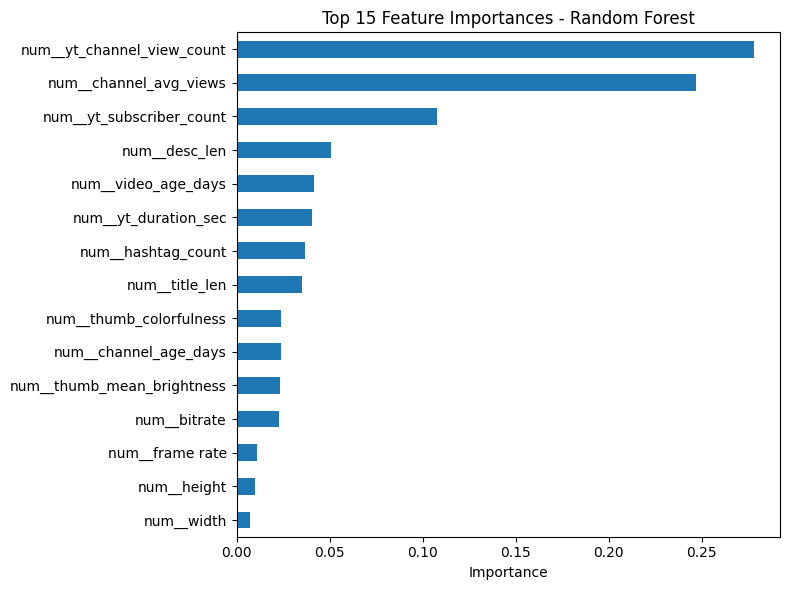

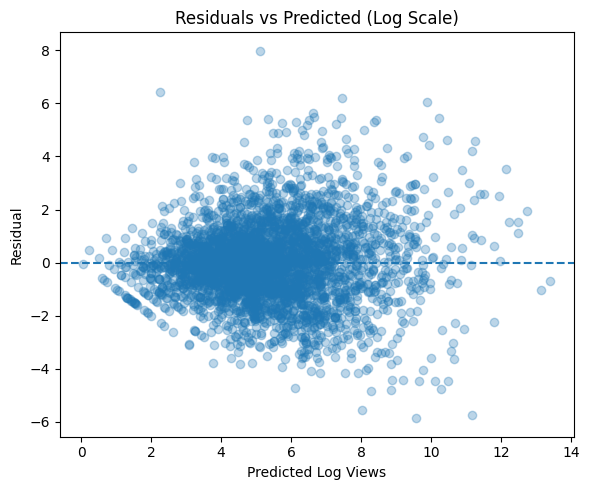

In [26]:

# RANDOM FOREST – TUNED MODEL (NO LEAKAGE)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import randint

RANDOM_STATE = 42

# IMPORTANT: ensure no post-publication leakage
# (likes/comments should NOT be in X)

rf_base_pipe = Pipeline([
    ('prep', preprocessor_unscaled),
    ('model', RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Hyperparameter Search Space
param_dist = {
    'model__n_estimators': randint(300, 800),
    'model__max_depth': [None, 20, 40, 60],
    'model__min_samples_split': randint(2, 15),
    'model__min_samples_leaf': randint(1, 5),
    'model__max_features': ['sqrt', 'log2', 0.5]
}

rf_search = RandomizedSearchCV(
    estimator=rf_base_pipe,
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# Fit Model
rf_search.fit(X_train, y_train)

print("\nBest RF Parameters:")
print(rf_search.best_params_)

print("\nBest CV RMSE (log views):")
print(-rf_search.best_score_)


# Evaluate on Test Set
rf_best_pipe = rf_search.best_estimator_
rf_preds_log = rf_best_pipe.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds_log))
rf_mae = mean_absolute_error(y_test, rf_preds_log)
rf_r2 = r2_score(y_test, rf_preds_log)

print("\nTest Metrics (log scale):")
print({
    'rmse_log_views': rf_rmse,
    'mae_log_views': rf_mae,
    'r2_log_views': rf_r2
})


# Back-Transform to Actual View Scale
actual_views = np.expm1(y_test)
pred_views = np.expm1(rf_preds_log)

rmse_views = np.sqrt(mean_squared_error(actual_views, pred_views))
mae_views = mean_absolute_error(actual_views, pred_views)

print("\nTest Metrics (actual view scale):")
print({
    'rmse_views': rmse_views,
    'mae_views': mae_views
})


# Add to Results Table
results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        'model': 'RandomForest_Tuned',
        'rmse_log_views': rf_rmse,
        'mae_log_views': rf_mae,
        'r2_log_views': rf_r2
    }])
], ignore_index=True).sort_values('rmse_log_views').reset_index(drop=True)

fitted_pipelines['RandomForest_Tuned'] = rf_best_pipe

print("\nUpdated Results Table:")
print(results_df)


# Feature Importance
print("\nTop 15 Feature Importances:")

feature_names = rf_best_pipe.named_steps['prep'].get_feature_names_out()
importances = rf_best_pipe.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names)
top_features = feat_imp.sort_values(ascending=False).head(15)

print(top_features)

plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh')
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


# Residual Plot
residuals = y_test - rf_preds_log

plt.figure(figsize=(6,5))
plt.scatter(rf_preds_log, residuals, alpha=0.3)
plt.axhline(0, linestyle='--')
plt.title("Residuals vs Predicted (Log Scale)")
plt.xlabel("Predicted Log Views")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

In [27]:
# Convert test predictions back to view scale for business interpretation ----
best_model_name = results_df.loc[0, 'model']
best_pipe = fitted_pipelines[best_model_name]
best_preds_log = best_pipe.predict(X_test)

compare = pd.DataFrame({
    'actual_views': np.expm1(y_test.values),
    'pred_views': np.expm1(best_preds_log)
})

compare['abs_error_views'] = (compare['actual_views'] - compare['pred_views']).abs()

print('Best model:', best_model_name)
print(compare[['actual_views', 'pred_views', 'abs_error_views']].describe())

Best model: RandomForest_Tuned
       actual_views     pred_views  abs_error_views
count  3.497000e+03    3497.000000     3.497000e+03
mean   2.202449e+04    2317.858110     2.097451e+04
std    2.835821e+05   18811.489902     2.785803e+05
min    0.000000e+00       0.061071     2.023379e-02
25%    4.000000e+01      61.531933     2.578750e+01
50%    1.550000e+02     187.966878     1.277418e+02
75%    9.160000e+02     650.245304     8.070398e+02
max    8.451637e+06  669248.214085     8.432087e+06


## Notes for Final Report

- This notebook confirms whether your available variables support all four models.
- If a candidate feature is missing, the pipeline still runs with available features.
- Keep the leakage rule (no likes/comments when predicting views).
- Remember you can add hyperparameter tuning (GridSearchCV/RandomizedSearchCV) after baseline comparison.

## Model Results and Literature Integration

### Random Forest Regressor (Primary Model)

The Random Forest model that was optimized using Tuning Parameters yielded the best performance when predicting the response variable (log-transformed view counts) (RMSE=1.507; R²=0.621), explained about 62% of the variation in the log-transformed view counts. In support of this, Hussain et al., (2024) found that "the number of subscribers in a YouTube channel has a consistent, positive effect on each of the three engagement tiers: Channels with more subscribers will have more views, likes and comments per video." Thus, you are using similar features of importance as Hussain et al., (2024) based upon your importance rankings of subscriber-based variables, which represent the largest portion of the predictor variables' ability to explain the response variable.

Furthermore, Hussain et al., (2024) also found that "there is an inverse relationship between total number of uploads and total engagement," therefore, it would make sense to use a normalized version of the raw upload volume, i.e., channel_avg_views, in order to capture a history of average performance, instead of simply capturing how many times the channel produces content.

Finally, the relative importance of thumbnail colorfulness and brightness in your Random Forest Model is also consistent with the findings of Koh and Cui, (2022), who demonstrated statistically significant relationships between these visual attributes of thumbnails and view-through rates (Koh & Cui, 2022, 7). Additionally, Koh and Cui (2022), argued that thumbnails featuring celebrities with both high colorfulness and high brightness were likely to persuade potential viewers to click and watch their videos. Although the explanatory value of thumbnail attributes were secondary to social capital variables in your model, they did provide a measurable amount of explanatory value to support models of persuasion in viewer decision making.

### Elastic Net Regression

Elastic Net produced relatively high R² scores (R² = 0.482) suggesting that the model explained about 48% of view variance, we still found its performance inferior to that of Random Forest. Thus, our findings suggest that the relationship of virality and the data used for the model is likely not linear. This is supported by Peng and Bainbridge (2026), who have argued that "memorable images were consistently associated with more comments" and that "memorability predicts viral potential independent of an image's emotional valence." Additionally, the authors indicate that the relationship of memorability is not solely additive or based on simply combining individual feature values. Rather, memorability functions primarily through "semantic distinctness," which means that the relationships between different components of the image and viewer interaction will be complex and nonlinear. Therefore, the lower performance of Elastic Net indicates that the exposure and content attributes of the images interacted in complex and non-additive ways.

### K-Nearest Neighbors (KNN)

The KNN Model (R² = .434) performed worse than both Elastic Net and Random Forest models indicating that virality is not being generated from a "local" similarity within feature space. Both the theoretical orientation and empirical findings support this as well; Hussain et al. (2024) point out that the amount of user engagement that occurs for a post is influenced by both the creator's variables and the user's response to the post rather than the isolated similarity of the post. Peng & Bainbridge (2026) also find that semantic distinctiveness was positively related to both memorability and virality (Peng & Bainbridge 2026, 2). These findings indicate that viral content is created through deeper cognitive processes rather than just similarity in metadata space. Thus KNN's poorer performance supports the hypothesis that virality has both structural/cognitive and neighborhood characteristics.

### Multi-Layer Perceptron (MLP)
The MLP model was shown to be the least accurate (R²= .206) as it suggests that increased levels of neural network complexity does not result in higher predictive accuracy for this structured metadata data set. As demonstrated by Gaur et al., (2024), Transformer based models can perform very well when utilized for the purpose of classifying large amounts of textual data, such as social media posts ("BERT achieved a 89.17% accuracy rate" as reported by Gaur et al., (2024)). However, the current data base is composed primarily of structured tabular attributes as opposed to the deeper semantic embedding typically found in textual data bases. In conclusion, the relative lower predictive accuracy of the MLP model is consistent with applied research in the field of machine learning that indicates that ensemble tree type models tend to outperform neural networks when used to predict from structured tabular data sets.

## Video Duration and Structural Metadata

As per our model, we found a moderate but very limited level of influence for yt_duration_sec. The results are in line with those of Konukoğlu and Özman (2025) as they also concluded that "they found no statistically significant linear relationships between video duration and the number of views, likes, or comments" (Konukoğlu and Özman 2025). Their research contradicts the widely held belief that simply using shorter videos will increase engagement and further emphasizes the need to consider the context and structure of the metadata when developing video content versus relying on simple duration based heuristics.

## Visual Atypicality and Conditional Effects
Our inclusion of thumbnail characteristics is consistent with the arguments of Adam and Yang (2025) which are as follows; "Visual atypicality increases an image's likelihood to be posted for use by a low heritage brand since it provides the consumer with additional entertainment." In contrast, "Visual atypicality decreases an image's likelihood to be posted for use by a high norm brand because the consumer expects consistency of visual appearance within each brand." Thus, the conditional relationship between visual atypicality and sharing an image indicates that the use of visually distinctive thumbnails will increase engagement when they align with both the expectations of the category and platform—consistent with your model's moderate non-dominant emphasis on thumbnail features.

## Integrated Interpretation
The data across each model confirm three basic propositions from the literature:
Creator social capital will be the best predictor of user engagement (Hussain et al. 2024) 
The click-through behavior on a thumbnail is influenced by both central and peripheral cues as well as visually and cognitively (Koh and Cui 2022). 
Memorability and semantic distinctness are independent of emotional intensity and represent two of the primary factors for determining viral success (Peng and Bainbridge 2026). Together, these findings provide further evidence to suggest that YouTube virality does not occur randomly, but rather is based upon a combination of the structure of how a video is exposed to users, its ability to stand out cognitively and how aligned it is with its context.

## Conclusion

This study set to determine what characteristics of video content best explain the likelihood of going viral on YouTube; with an emphasis on identifying pre-publishing predictors versus post-publishing indicators of engagement. With the aid of a large-scale data collection using a YouTube API and four classification-based modeling techniques (KNN, Elastic Net, Random Forest, MLP); the findings of this study show that social capital related to creators — specifically the number of subscribers and past historical views of their channel — represent the greatest predictors of viewer outcomes. The optimized Random Forest model used to generate predictions in this study represented an approximate 62% explanation of the total variance observed in log transformed views, thus representing a much greater explanatory power over baseline models built around linear regression and neural networks.

The findings presented in this study support Hussain et al.'s (2024) assertion that accumulated structural social capital has a significant impact on the tiered nature of engagement, because YouTube channels with the largest subscriber bases consistently received greater numbers of views, likes and comments. Additionally, measurable predictive strength was demonstrated for thumbnail colorfulness and brightness, as found in Koh and Cui's (2022) research demonstrating the importance of thumbnail aesthetics on influencing view-through behavior. Importantly, however, visual attributes (such as colorfulness and brightness) were shown to be secondary moderators relative to the magnitude of creator exposure metrics.

Furthermore, the findings of this study support the theoretical assertions made in Peng and Bainbridge's (2026) research on memorability, where it was found that semantic distinctiveness predicted virality independent of emotional intensity. Although this study utilized relatively light-weight thumbnail representations instead of utilizing deep semantic embeddings, the demonstrated importance of thumbnails in predicting viewer behaviors provides evidence supporting the assertion that cognitive salience impacts engagement.

Moreover, the results of this study confirm that while post-publishing engagement measures (i.e. likes and comments) are able to nearly perfectly explain viewer variance, they do not serve as useful predictors prior to publishing. Therefore, the engagement measures were excluded from the models to allow for the identification of factors observable at or shortly after the time of publishing. The results of this study provide a more realistic understanding of the mechanisms underlying YouTube virality: while virality can be influenced by a variety of factors (i.e. creator reputation, thumbnail presentation), its ultimate success is based upon the presence of structural conditions present in the YouTube environment.

Future studies could potentially expand this framework by incorporating additional forms of visual representations (deep semantic embeddings), temporal validation splits or multi-view representation learning methods (i.e. Jing et al. (2018)) to further model interactions between different types of media representations. Overall, the findings suggest that predicting virality on YouTube to some degree is possible, but extremely high outliers will continue to be very difficult to predict due to the inherent randomness associated with all digital diffusion processes.

## References

Adam, Zitian, and Zhiyong Yang. 2025. “Breaking the Mold: How Visual Atypicality Shapes Brand-Generated Image Virality.” *International Journal of Research in Marketing*. Advance online publication. https://doi.org/10.1016/j.ijresmar.2025.07.005.

Baravkar, A., R. Jaiswal, J. Chhoriya, and B. Tekwani. 2021. “Sentimental Analysis of YouTube Videos.” *International Journal of Scientific Research in Computer Science, Engineering and Information Technology*. https://doi.org/10.32628/cseit2172112.

Endait, Ojaswi, Mahalakshmi Iyer, Urvi Somashetti, Komal Zoting, and Dhananjay Bhagat. 2025. “YouTube Trending Video Analysis Using Natural Language Processing and Machine Learning.” In *2025 International Conference on Sustainability, Innovation & Technology (ICSIT)*, 1–5. IEEE. https://doi.org/10.1109/ICSIT65336.2025.11295060.

Gaur, Adamya, Sanjay Kumar Singh, and Pranshu Saxena. 2024. “Performance Analysis of Deepfake Text Detection Techniques on Social-Media.” In *International Conference on Distributed Computing and Optimization Techniques (ICDCOT)*, 1–6. IEEE. https://doi.org/10.1109/ICDCOT61034.2024.10515626.

Hussain, K., K. Nusair, M. Junaid, and W. Aman. 2024. “A Two-Actor Model for Understanding User Engagement with Content Creators: Applying Social Capital Theory.” *Computers in Human Behavior* 156: 108237. https://doi.org/10.1016/j.chb.2024.108237.

Jing, Peiguang, Yuting Su, Liqiang Nie, Xu Bai, Jing Liu, and Meng Wang. 2018. “Low-Rank Multi-View Embedding Learning for Micro-Video Popularity Prediction.” *IEEE Transactions on Knowledge and Data Engineering* 30 (8): 1519–1532. https://doi.org/10.1109/TKDE.2017.2785784.

Koh, Byungwan, and Fuquan Cui. 2022. “An Exploration of the Relation Between the Visual Attributes of Thumbnails and the View-Through of Videos: The Case of Branded Video Content.” *Decision Support Systems* 160: 113820. https://doi.org/10.1016/j.dss.2022.113820.

Konukoğlu, L., and M. F. Özman. 2025. “Video Duration and Engagement in Mathematics Instruction on YouTube: An Analysis of Content-Level Moderators.” *International Journal of Curriculum and Instruction* 17 (3): 689–711. https://ijci.net/index.php/IJCI/article/view/1633.

Peng, Shikang, and Wilma A. Bainbridge. 2026. “Image Memorability Predicts Social Media Virality and Externally-Associated Commenting.” *Computers in Human Behavior* 174: 108799. https://doi.org/10.1016/j.chb.2025.108799.

CyberEvil545. 2025. *YouTube Videos Data for ML and Trend Analysis*. Kaggle. https://www.kaggle.com/datasets/cyberevil545/youtube-videos-data-for-ml-and-trend-analysis.